## A Tutorial Example
In this example, I am going to use an example involving fitting a pploynomial to a small dataset to learn the basic concepts and much of the terminology of DL. This is a form of supservised learning where we going to prediction a target variable __t__ given and input variable __x__

### Synthetic data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# np.random.seed(1)

In [2]:
N = 10
x = np.linspace(0,1,N)
print(x)

[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


In [3]:
y = np.sin(2 * np.pi * x) + np.random.normal(0, 0.25, N)
print(y)

[-0.19625892  0.94421585  0.791419    1.35329812  0.47921816 -0.37772396
 -1.16035243 -0.76153922 -0.40755995 -0.01032988]


Text(0, 0.5, 'y')

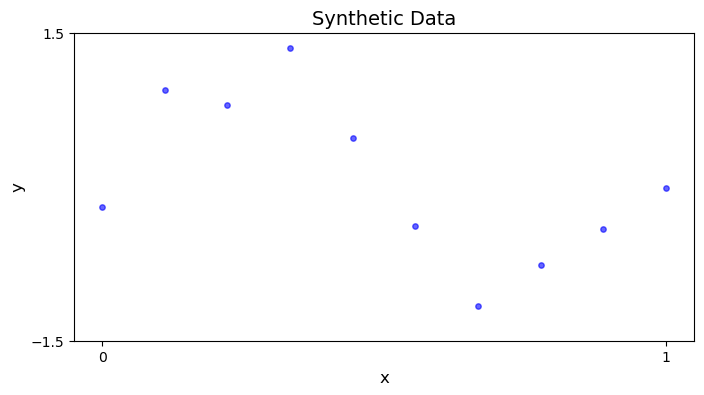

In [4]:
plt.figure(figsize=(8,4))
plt.scatter(x, y, color='b', s=15, alpha=0.6)
plt.title('Synthetic Data', fontsize=14)
plt.xticks([0, 1])
plt.yticks([-1.5 ,1.5])
plt.xlabel('x',fontsize=12)
plt.ylabel('y', fontsize=12)

### Linear Models

- Our goal here to predict the value $\hat{y}$ of the target variable for some new value $\hat{x}$ of the input varable.
- This is a difficult problem becasue we are trying unconver the underlying mathematical function that produced this data from a finite data sets.
- Also the observed data for some input value __x__ is corrupted by noise so we are unsure about the appropriate value of the target variable
- __Probability Theory__ provide a framework to express the uncertainty and a precise and quantitative manner
- __Decision Theory__ use the probabilistic representataion to make predictions that are optimal according to some appropriate creteria
- Let start rather informally by fitting our data with a polynomial
- Although the polynomial is nonlinear in __x__ and it linear in the coefficients __w__. Models that are linear in the unknown parameters are called __Linear Models__


  $y(x,w)$ = $w_0$ + $w_1x$ + $w_2x^2$+ ... + $w_Mx^M$ = $ \sum_{j=1}^{M} w_jx^j $

### Error Function

- The values of the coefficients __w__ can be obtained by fitting the polynomial to the training data
- This can be done by minimizing an error function, which is a measure of the misfit between the function y(x,__w__) for a given value __w__ and the training set
- A popular error function is the sum of the squares of the difference between the prediction y(x,__w__) for the input x and corresponding target target value t
- This error function can be solve in close form by finding the derivative of wrt to w, and since the derivative will be linear, the solution will be unique : $y(x,w^*)$

$E(w)$ = $\frac{1}{2}\sum_{n=1}^{N}\{y(x,w)-t_n\}^2$

### Model Complexity
- The next task is to choose the order of the polynomial and this is an important concept called model selection or model complexity
- When $M=0$ and $M=1$ the polynomial fits poorly to the training data and consequently gives poor representation of the underlying function. This is know as underfitting. The model is too simple for data and therefore it is not able to capture the underlying representatio of the data.
- It is observed that M=3 fits the data well and it able to represent the underlying function well.
- When $M=9$, the training RMSE drops to zero as the model completely memorizes the training data. However, the resulting fitted curve gives a poor representation of the underlying function. This is known as overfitting. The model has too much complexity for the small training dataset, causing it to fit the random noise rather than the true underlying pattern.

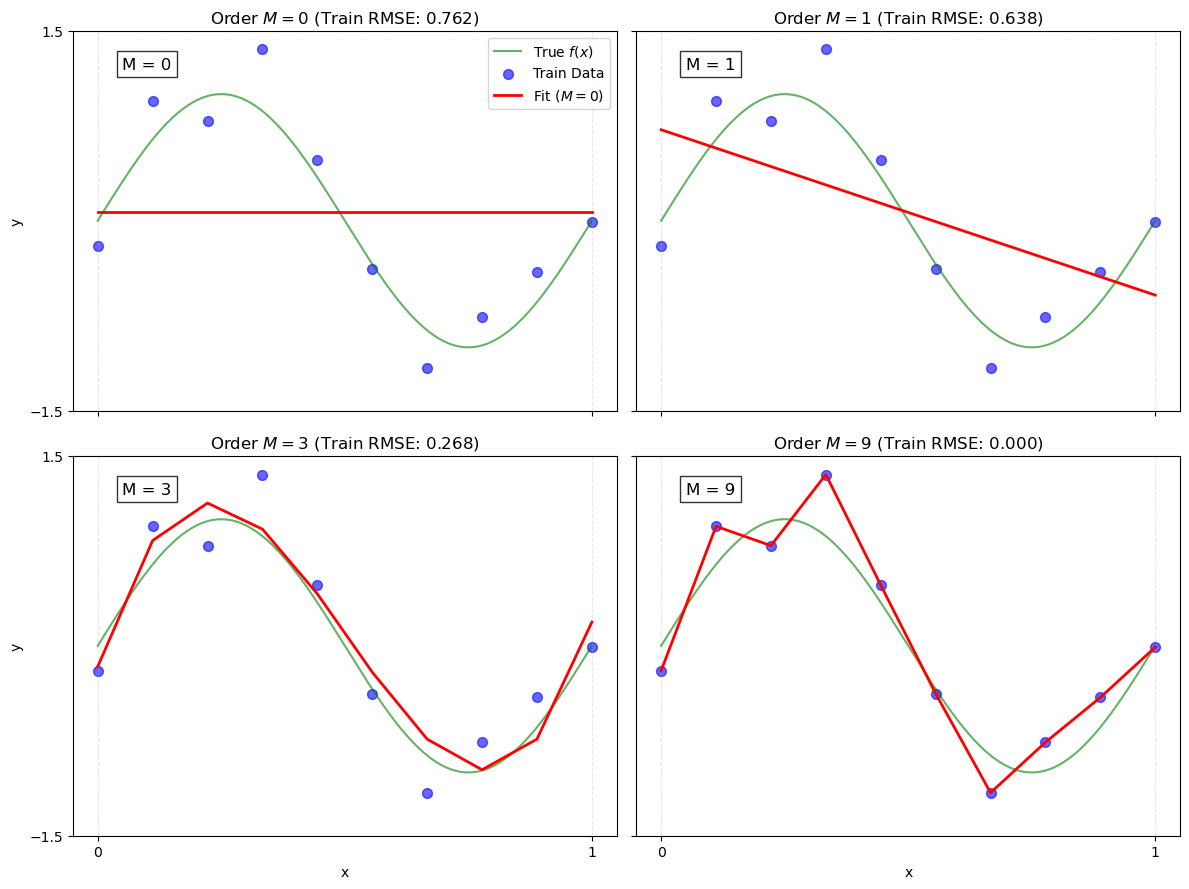

In [5]:
# Generate a dense grid to plot the true curve and the smooth fitted model
x_dense = np.linspace(0, 1, num=200)
y_true = np.sin(2 * np.pi * x_dense)
x_train, y_train = x, y

# 2. Generate Testing Data (100 completely new points to check generalization)
n_test = 100
x_test = np.linspace(0, 1, num=n_test)
y_test = np.sin(2 * np.pi * x_test) + np.random.normal(loc=0.0, scale=0.15, size=n_test)

# set up a 2 x 2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12,9), sharex=True, sharey=True)
axes = axes.flatten()

orders = [0, 1, 3, 9]

# Fit models and plot for each order M
for i, M in enumerate(orders):
    ax = axes[i]

    # Find the optimal weights (coefficients) using the Least Squares error function
    w = np.polyfit(x_train,y_train,deg=M)

    # Create a polynomial function object from those weights
    polynomial_model = np.poly1d(w)

     # Predict values across the dense x-axis
    y_pred = polynomial_model(x_train)

    # Calculate the training root-mean-square error (RMSE) for context
    train_rmsq = np.sqrt(np.mean((polynomial_model(x_train) - y_train)**2))

    # Plotting data on the current subplot
    ax.plot(x_dense, y_true, color='green', linestyle='-', alpha=0.6, label='True $f(x)$')
    ax.scatter(x_train, y_train, color='b', alpha=0.6, s=50, label='Train Data')
    ax.plot(x_train, y_pred, color='red', linewidth=2, label=f'Fit ($M={M}$)')

    # Subplot Styling
    ax.set_title(f'Order $M = {M}$ (Train RMSE: {train_rmsq:.3f})')
    ax.text(0.05, 1.2, f'M = {M}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    # ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([0, 1.0])
    ax.set_yticks([-1.5, 1.5])
    ax.grid(True, linestyle='--', alpha=0.3)
    if i >= 2: ax.set_xlabel('x')
    if i % 2 == 0: ax.set_ylabel('y')
    if i == 0: ax.legend(loc='upper right')
      
plt.tight_layout()
plt.show()
    

### $E_{RMS}$ vs $M$
- Note that instead of using the sum of squared differences, Root Mean Squared Error $E_{\text{RMS}}$ is normally used for the evaluation function. This enables us to compare datasets of different sizes on the same footing. It also ensures that the residual error is measured on the exact same scale as the target variable.

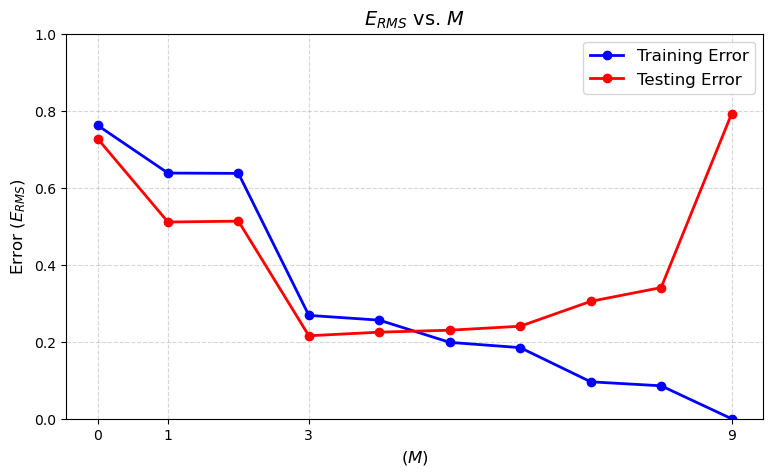

In [8]:
# Generate a dense grid to plot the true curve and the smooth fitted model
n=10
x_train = x
y_train = y

# 2. Generate Testing Data (100 completely new points to check generalization)
n_test = 100
x_test = np.linspace(0, 1, num=n_test)
y_test = np.sin(2 * np.pi * x_test) + np.random.normal(loc=0.0, scale=0.15, size=n_test)

orders = np.arange(0,10)
train_errors = []
test_errors = []

for M in orders:
    # Fit the polynomial weights to the TRAINING data only
    w = np.polyfit(x_train, y_train, deg=M)
    model = np.poly1d(w)

    # calculate the training erms
    y_train_pred = model(x_train)
    train_rmse = np.sqrt(np.mean((y_train_pred - y_train)**2))
    train_errors.append(train_rmse)

    # Calculate Testing ERMS (Evaluating on unseen data)
    y_test_pred = model(x_test)
    test_rmse = np.sqrt(np.mean((y_test_pred - y_test) ** 2))
    test_errors.append(test_rmse)

##5. Create the ERMS vs. M validation plot
plt.figure(figsize=(9, 5))
plt.plot(orders, train_errors, marker='o', color='blue', label='Training Error', linewidth=2)
plt.plot(orders, test_errors, marker='o', color='red', label='Testing Error', linewidth=2)
    

# Styling
plt.title(r'$E_{RMS}$ vs. $M$', fontsize=14)
plt.xlabel('($M$)', fontsize=12)
plt.ylabel(r'Error ($E_{RMS}$)', fontsize=12)
plt.xticks([0,1,3,9])  # Show integer marks for every M value
plt.ylim(0, 1.0)    # Cap the Y-axis so exploding M=9 test errors don't squash the chart
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.show()

### Regularization

- We observed that for models that overfit, the magnitudes of the weights become exceptionally large. One powerful technique used to tackle this overfitting problem is regularization. This entails adding a penalty term to the error function to discourage the weights from taking on larger values.
  $$ E(w) = \frac{1}{2}\sum_{n=1}^{N}\{y(x_n,w)-t_n\}^2 + \frac{\lambda}{2}\|w\|^2 $$


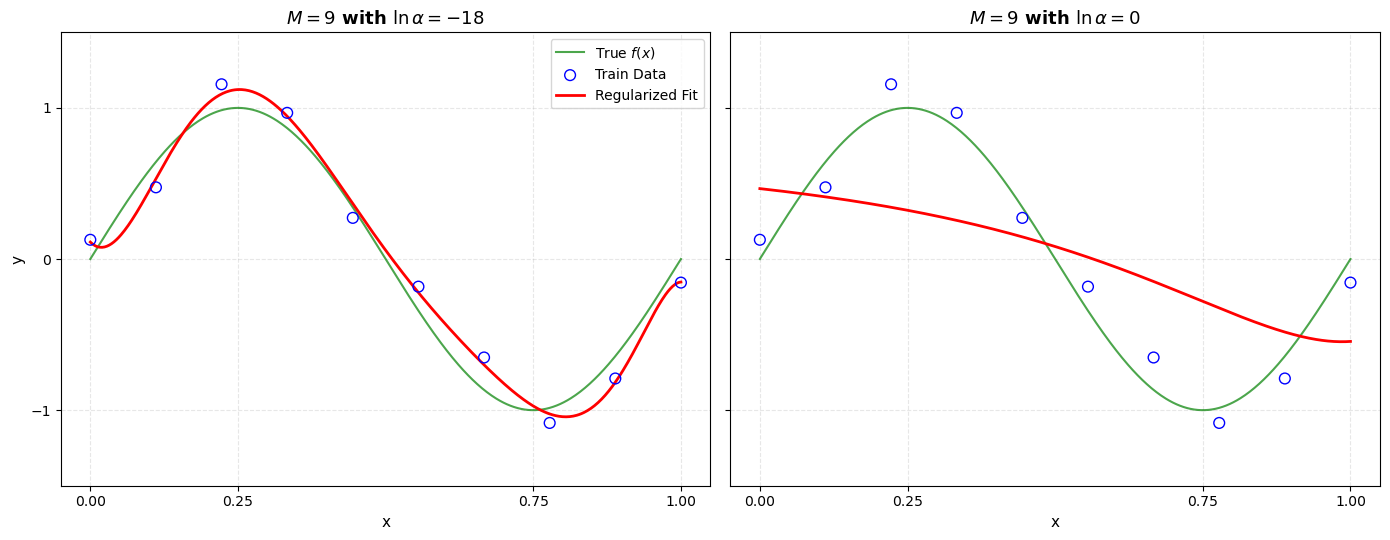

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# 1. Generate the training dataset (10 points, balanced seed 83)
np.random.seed(83)
n_train = 10
# Scikit-learn requires 2D arrays for the input features (X)
X_train = x.reshape(-1, 1)
y_train = np.sin(2 * np.pi * X_train.ravel()) + np.random.normal(loc=0.0, scale=0.15, size=n_train)

# Dense grids for smooth curve evaluation
X_dense = np.linspace(0, 1, num=500).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X_dense.ravel())

# 2. Set up the 1 row, 2 column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

# Define the two lambda/alpha values to compare using natural logs
ln_alphas = [-18, 0]

for i, ln_alpha in enumerate(ln_alphas):
    ax = axes[i]
    alpha_val = np.exp(ln_alpha)  # Convert ln(alpha) back to raw alpha numerical value
    
    # 3. Create and train the Scikit-learn Polynomial Ridge Regression model
    # include_bias=False prevents generating a duplicate intercept column
    model = make_pipeline(
        PolynomialFeatures(degree=9, include_bias=False),
        Ridge(alpha=alpha_val)
    )
    model.fit(X_train, y_train)
    
    # 4. Generate predictions across the dense grid
    y_pred = model.predict(X_dense)
    
    # 5. Plot everything
    ax.plot(X_dense, y_true, color='green', linestyle='-', alpha=0.7, label='True $f(x)$')
    ax.scatter(X_train, y_train, color='blue', facecolors='none', edgecolors='blue', s=60, zorder=3, label='Train Data')
    ax.plot(X_dense, y_pred, color='red', linewidth=2, label='Regularized Fit')
    
    # Styling and Titles
    ax.set_title(f'$M = 9$ with $\ln\\alpha = {ln_alpha}$', fontsize=13, fontweight='bold')
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('x', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Clean axis ticks
    ax.set_xticks([0, 0.25, 0.75, 1.0])
    ax.set_yticks([-1.0, 0, 1.0])
    
    if i == 0:
        ax.set_ylabel('y', fontsize=11)
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


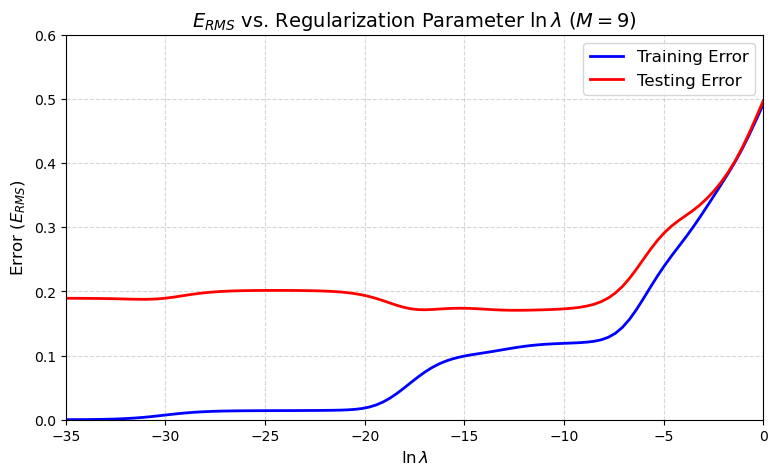

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

# 1. Generate Training Data (10 points, seed 83)
np.random.seed(83)
n_train = 10
X_train = x.reshape(-1, 1)
y_train = np.sin(2 * np.pi * X_train.ravel()) + np.random.normal(loc=0.0, scale=0.15, size=n_train)

# 2. Generate Testing Data (100 new points to check generalization)
n_test = 100
X_test = np.linspace(0, 1, num=n_test).reshape(-1, 1)
y_test = np.sin(2 * np.pi * X_test.ravel()) + np.random.normal(loc=0.0, scale=0.15, size=n_test)

# 3. Define a range of ln(lambda) values from -35 to 0
ln_lambdas = np.linspace(-35, 0, 100)
train_errors = []
test_errors = []

# 4. Loop through lambdas to compute ERMS
for ln_lmbda in ln_lambdas:
    lmbda_val = np.exp(ln_lmbda)  # Convert ln(lambda) to raw value
    
    # Fit 9th-degree polynomial with regularized Ridge regression
    model = make_pipeline(
        PolynomialFeatures(degree=9, include_bias=False),
        Ridge(alpha=lmbda_val)
    )
    model.fit(X_train, y_train)
    
    # Calculate Training ERMS
    y_train_pred = model.predict(X_train)
    train_rmse = np.sqrt(np.mean((y_train_pred - y_train) ** 2))
    train_errors.append(train_rmse)
    
    # Calculate Testing ERMS
    y_test_pred = model.predict(X_test)
    test_rmse = np.sqrt(np.mean((y_test_pred - y_test) ** 2))
    test_errors.append(test_rmse)

# 5. Create the ln(lambda) vs. ERMS plot
plt.figure(figsize=(9, 5))
plt.plot(ln_lambdas, train_errors, color='blue', label='Training Error', linewidth=2)
plt.plot(ln_lambdas, test_errors, color='red', label='Testing Error', linewidth=2)

# Styling
plt.title(r'$E_{RMS}$ vs. Regularization Parameter $\ln\lambda$ ($M=9$)', fontsize=14)
plt.xlabel(r'$\ln\lambda$', fontsize=12)
plt.ylabel(r'Error ($E_{RMS}$)', fontsize=12)
plt.xlim(-35, 0)
plt.ylim(0, 0.6)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.show()
